In [4]:
#Preamble
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pydicom as dcm
import math
import os

### What I did

When simulating the cell irradiation setup in RayStation the issue is that due to a safety margin I need to set the snout position in the simulation 0.13 cm lower than in reality (at 8.19 instead of 8.06). The question is whether this matters for the simulated dose and LET in the cell layer.
Therefore I did the simulation with the same setup and beam for 8.19 cm and 8.32 cm snout position. The plan is calculated to deliver 2 Gy physical dose to the cell layer without anything in the beam path. For the simulation I used 7 mm solid water + RS2 range shifter to really push to the end of the Bragg Peak. 
![alt text](<../Snout position results/Simulation for snout position.png>)

First indications based on dose/let stats given in Raystation (min, max, avg) say it doesn't matter.

In [49]:
data_pos1 = pd.read_csv(r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Snout position results\Test flask plan - Testing snout position difference\roi_let_dose_coords cell layer snout 8.19.csv")
data_pos2 = pd.read_csv(r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Snout position results\Test flask plan - Testing snout position difference\roi_let_dose_coords cell layer snout 8.32.csv")

In [50]:
#Due to the fineness of the dose grid the cell layer also has multiple depth values
#I'll map the first one
slice_pos1 = data_pos1[data_pos1['y_mm']==data_pos1['y_mm'].unique()[0]]
slice_pos2 = data_pos2[data_pos2['y_mm']==data_pos2['y_mm'].unique()[0]]

#Set up image array
x_vals = slice_pos1['x_mm'].unique()
z_vals = slice_pos2['z_mm'].unique()
let_pos1 = np.zeros([int(len(z_vals)), int(len(x_vals))])
let_pos2 = np.zeros([int(len(z_vals)), int(len(x_vals))])
dose_pos1 = np.zeros([int(len(z_vals)), int(len(x_vals))])
dose_pos2 = np.zeros([int(len(z_vals)), int(len(x_vals))])

#Populate image array with LET values
for i in slice_pos1.index.tolist():
    datapoint = slice_pos1.loc[i]
    x = datapoint.x_mm
    z = datapoint.z_mm
    let = datapoint.LET_keV_per_um
    dose = datapoint.Dose_Gy

    x_index = np.where(x_vals == x)
    z_index = np.where(z_vals == z)

    let_pos1[z_index, x_index] = let
    dose_pos1[z_index, x_index] = dose

#Populate image array with LET values
for i in slice_pos2.index.tolist():
    datapoint = slice_pos2.loc[i]
    x = datapoint.x_mm
    z = datapoint.z_mm
    let = datapoint.LET_keV_per_um
    dose = datapoint.Dose_Gy

    x_index = np.where(x_vals == x)
    z_index = np.where(z_vals == z)

    let_pos2[z_index, x_index] = let
    dose_pos2[z_index, x_index] = dose

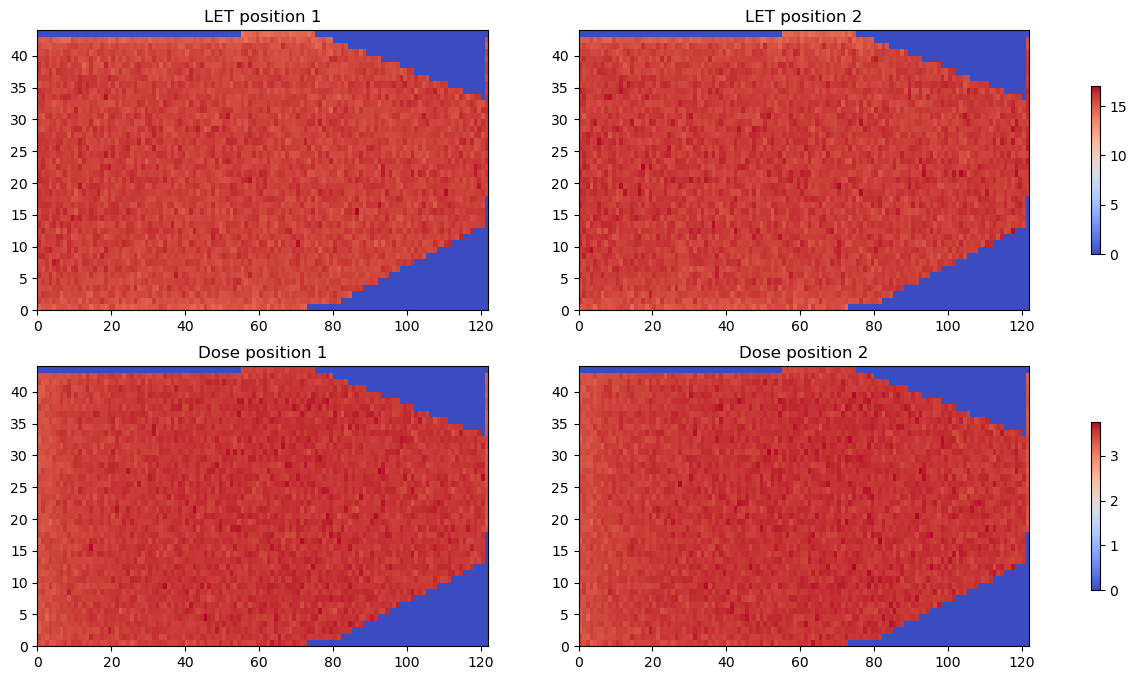

In [55]:
#plot LET and dose
fig, axes = plt.subplots(nrows=2,ncols=2, figsize=(16, 8))

data = ((let_pos1, let_pos2), (dose_pos1, dose_pos2))
titles = (('LET position 1', 'LET position 2'), ('Dose position 1', 'Dose position 2'))

for row in range(2):
    for col in range(2):
        ax = axes[row, col]
        ax.set_title(titles[row][col])
        pcm = ax.pcolormesh(data[row][col], cmap='coolwarm')
    fig.colorbar(pcm, ax=axes[row, :], shrink=0.6)

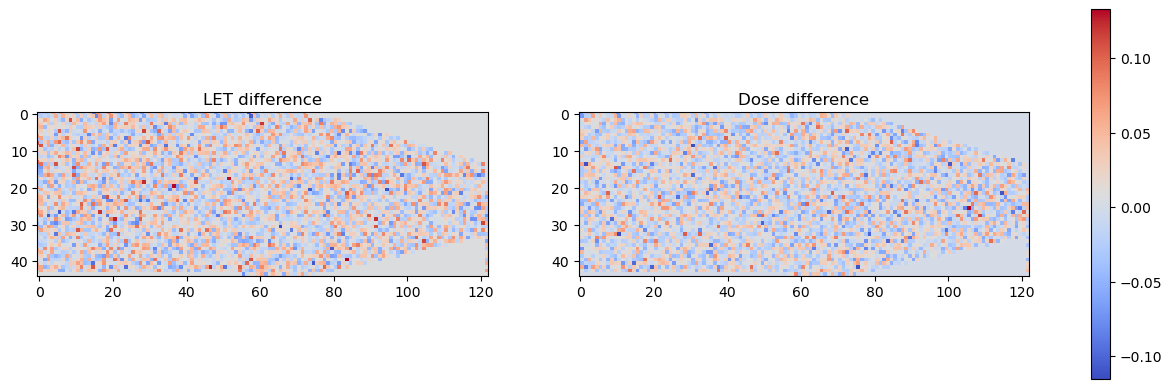

In [59]:
#Plot differences
fig, axes = plt.subplots(nrows=1,ncols=2, figsize=(16, 8))

data = (let_pos1-let_pos2, dose_pos1-dose_pos2)
titles = ('LET difference', 'Dose difference')

axes[0].imshow((let_pos1-let_pos2),cmap='coolwarm')
axes[0].set_title('LET Difference')

axes[1].imshow((dose_pos1-dose_pos2),cmap='coolwarm')
axes[1].set_title('Dose Difference')


for col in range(2):
    ax = axes[ col]
    ax.set_title(titles[col])
    pcm = ax.pcolormesh(data[col], cmap='coolwarm')
fig.colorbar(pcm, ax=axes, shrink=0.6)

The differences are very small, +-0.1

In [63]:
#Print statistics
print("----Position 1 data----")
print("Mean dose: " + str(round(np.mean(dose_pos1),2)) + " Gy")
print("Max dose: " + str(round(np.max(dose_pos1),2)) + " Gy")
print("Min dose: " + str(round(np.min(dose_pos1),2)) + " Gy")
print("Mean LET: " + str(round(np.mean(let_pos1),2)) + " keV/um")
print("Max LET: " + str(round(np.max(let_pos1),2)) + " keV/um")
print("Min LET: " + str(round(np.min(let_pos1),2)) + " keV/um")

print("----Position 2 data----")
print("Mean dose: " + str(round(np.mean(dose_pos2),2)) + " Gy")
print("Max dose: " + str(round(np.max(dose_pos2),2)) + " Gy")
print("Min dose: " + str(round(np.min(dose_pos2),2)) + " Gy")
print("Mean LET: " + str(round(np.mean(let_pos2),2)) + " keV/um")
print("Max LET: " + str(round(np.max(let_pos2),2)) + " keV/um")
print("Min LET: " + str(round(np.min(let_pos2),2)) + " keV/um")

----Position 1 data----
Mean dose: 3.13 Gy
Max dose: 3.76 Gy
Min dose: 0.0 Gy
Mean LET: 14.02 keV/um
Max LET: 17.13 keV/um
Min LET: 0.0 keV/um
----Position 2 data----
Mean dose: 3.13 Gy
Max dose: 3.75 Gy
Min dose: 0.0 Gy
Mean LET: 14.02 keV/um
Max LET: 17.01 keV/um
Min LET: 0.0 keV/um
